<h1 style="text-align:center; color:#ff4d4d;">
Customer Churn Analysis and Prediction
</h1>


# **1.SUMMARY**

* The Telco Customer Churn dataset contains demographic, service subscription, and billing information of telecom customers, with the primary objective of identifying whether a customer will continue using the company’s services or leave (churn). It includes features such as tenure, contract type, internet services, monthly charges, and total spending, providing insights into customer behavior, loyalty patterns, and revenue contribution. This dataset is widely used for classification analysis in customer retention and business decision-making contexts.


* In this project, we performed end-to-end data analysis and machine learning modeling to understand the factors influencing customer churn and to build predictive models for churn detection. The workflow included data cleaning, feature engineering, exploratory data analysis, visualization of key churn trends, and training classification models such as Random Forest and Gradient Boosting. The goal was to generate actionable insights that help telecom companies improve customer retention strategies and make data-driven business decisions.

---

# **2.Column descriptions**

`customerID` → Unique identifier assigned to each customer.

`gender` → Indicates whether the customer is male or female.

`SeniorCitizen` → Shows if the customer is a senior citizen (1 = Yes, 0 = No).

`Partner` → Whether the customer has a partner.

`Dependents` → Whether the customer has dependents.

`tenure` → Number of months the customer has stayed with the company.

`PhoneService` → Indicates if the customer subscribes to phone service.

`MultipleLines` → Whether the customer has multiple phone lines.

`InternetService` → Type of internet service used (DSL, Fiber optic, or None).

`OnlineSecurity` → Availability of online security service.

`OnlineBackup` → Availability of online backup service.

`DeviceProtection` → Availability of device protection plan.

`TechSupport` → Availability of technical support service.

`StreamingTV` → Whether the customer uses TV streaming service.

`StreamingMovies` → Whether the customer uses movie streaming service.

`Contract` → Type of contract subscribed (month-to-month, one year, two year).

`PaperlessBilling` → Indicates if the customer uses paperless billing.

`PaymentMethod` → Mode of payment used by the customer.

`MonthlyCharges` → Monthly bill amount charged to the customer.

`TotalCharges` → Total amount charged to the customer during their tenure.

`Churn` → Target variable indicating whether the customer left the company (Yes/No).

----

# **3.Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pickle
import warnings
warnings.filterwarnings('ignore')

-----

#  **4.Load Dataset**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4062,1915-IOFGU,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,70.50,70.5,Yes
4459,3178-FESZO,Female,0,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.25,100.25,Yes
782,0285-INHLN,Male,0,Yes,Yes,27,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),54.75,1510.3,No
5899,9943-VSZUV,Male,1,No,No,67,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,75.70,5060.85,No
4791,7808-DVWEP,Male,0,Yes,No,3,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.00,49.65,No


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


------

# **5.Removing Unnecessary Columns**

In [5]:
df = df.drop(['customerID'], axis = 1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


-----

# **6.Exploring Unique Values in Categorical Columns**

In [6]:
features = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in df.columns:
  if col not in features:
    print(col, df[col].unique())
    print('-----------------------------')

gender ['Female' 'Male']
-----------------------------
SeniorCitizen [0 1]
-----------------------------
Partner ['Yes' 'No']
-----------------------------
Dependents ['No' 'Yes']
-----------------------------
PhoneService ['No' 'Yes']
-----------------------------
MultipleLines ['No phone service' 'No' 'Yes']
-----------------------------
InternetService ['DSL' 'Fiber optic' 'No']
-----------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
-----------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
-----------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
-----------------------------
TechSupport ['No' 'Yes' 'No internet service']
-----------------------------
StreamingTV ['No' 'Yes' 'No internet service']
-----------------------------
StreamingMovies ['No' 'Yes' 'No internet service']
-----------------------------
Contract ['Month-to-month' 'One year' 'Two year']
-----------------------------
PaperlessBilling ['Yes' 'No']


-----

# **7.Explore column `TotalCharhges`**

The col TotalCharges have string and it have some values like "    ".First replace "    " with NaN

In [7]:
df.iloc[488].TotalCharges

' '

In [8]:
# convert object → numeric (blank values become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

------

# **8.Handle the missing values in `TotalCharges`**

In [10]:
# replace missing values with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [11]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

-----

# **9.Add new Column `customer_stage`**

in this column we divede the tenure in three class New(tenure <= 12) , Mid(12 < tenure <= 48) and Loyal(tenure > 48)

In [13]:
def tenure_stage(x):
    if x <= 12:
        return "New"
    elif x <= 48:
        return "Mid"
    else:
        return "Loyal"

df['customer_stage'] = df['tenure'].apply(tenure_stage)

In [14]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customer_stage
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Mid
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Mid
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New


-----

# **10.Exploratory Data Analysis (EDA)**

In [15]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [16]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [17]:
517400/df.shape[0]

73.46301292063042

-----

# **11.Visualizing Churn Distribution**

(array([0, 1]), [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

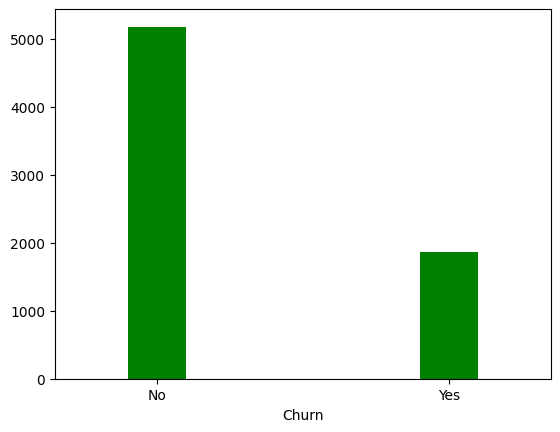

In [18]:
df["Churn"].value_counts().plot(kind='bar' , color = 'green' , width = 0.2);
plt.xticks(rotation = 'horizontal')

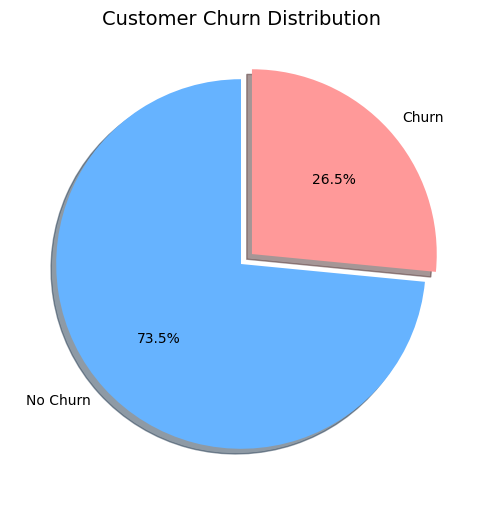

In [19]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))

colors = ['#66b3ff', '#ff9999']   # soft blue & soft red

plt.pie(churn_counts,
        labels=['No Churn','Churn'],
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        explode=[0,0.08],
        shadow=True)

plt.title("Customer Churn Distribution", fontsize=14)
plt.show()

------

# **12.Visualization on Dataset**

## **Heatmap for correlation**

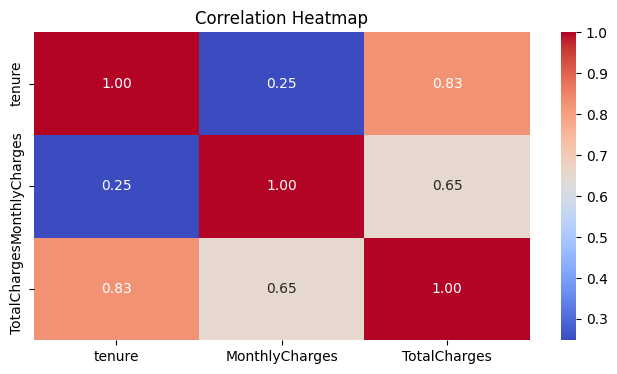

In [20]:
plt.figure(figsize=(8, 4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**`Tenure vs TotalCharges`**: Strong positive correlation → customers who stay longer generate higher total revenue.

**`MonthlyCharges vs TotalCharges`**: Moderate positive correlation → higher monthly plans lead to greater overall spending.

**`Tenure vs MonthlyCharges`**: Weak positive correlation → monthly billing is only slightly related to how long customers stay.


## **`Chrun` vs `tenure`**

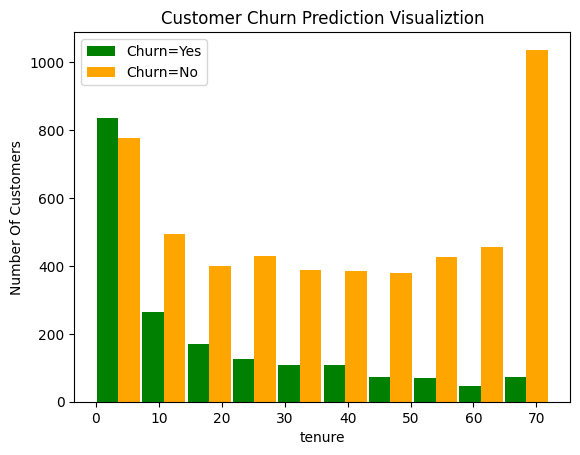

In [21]:
tenure_churn_no = df[df.Churn=='No'].tenure
tenure_churn_yes = df[df.Churn=='Yes'].tenure

plt.xlabel("tenure")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualiztion")

plt.hist([tenure_churn_yes, tenure_churn_no], rwidth=0.95, color=['green','orange'],label=['Churn=Yes','Churn=No'])
plt.legend()

## **`Chrun vs MonthlyCharges`**

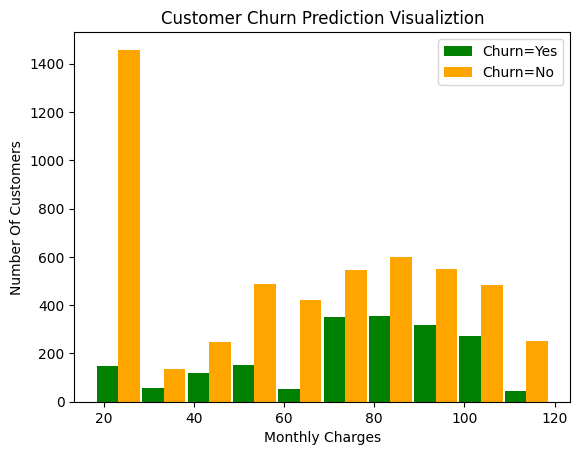

In [22]:
mc_churn_no = df[df.Churn=='No'].MonthlyCharges      
mc_churn_yes = df[df.Churn=='Yes'].MonthlyCharges      

plt.xlabel("Monthly Charges")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualiztion")

plt.hist([mc_churn_yes, mc_churn_no], rwidth=0.95, color=['green','orange'],label=['Churn=Yes','Churn=No'])
plt.legend()

## **`Chrun` vs `Contract`**

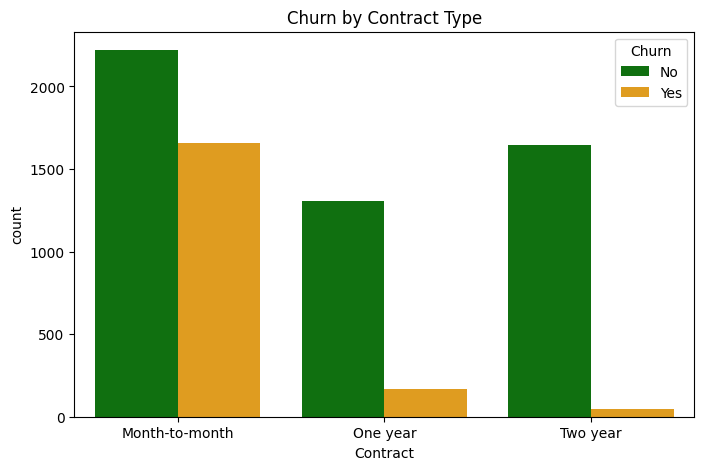

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette=['green', 'orange'])
plt.title('Churn by Contract Type')
plt.show()

## **`Chrun` vs `InternetService`**

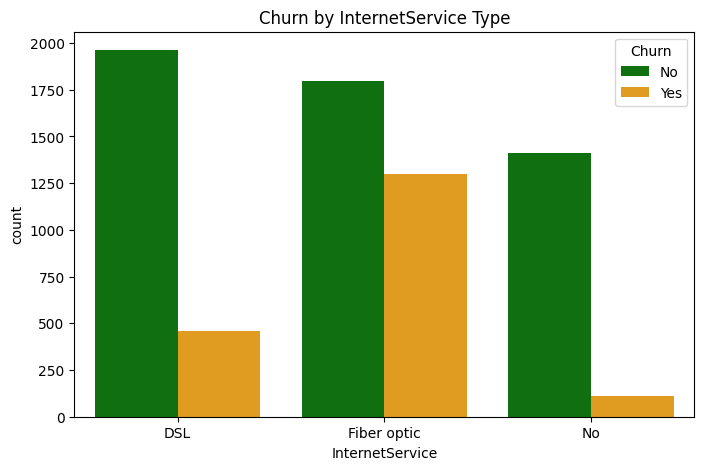

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df, palette=['green', 'orange'])
plt.title('Churn by InternetService Type')
plt.show()

## **`Churn` vs `PaymentMethod`**

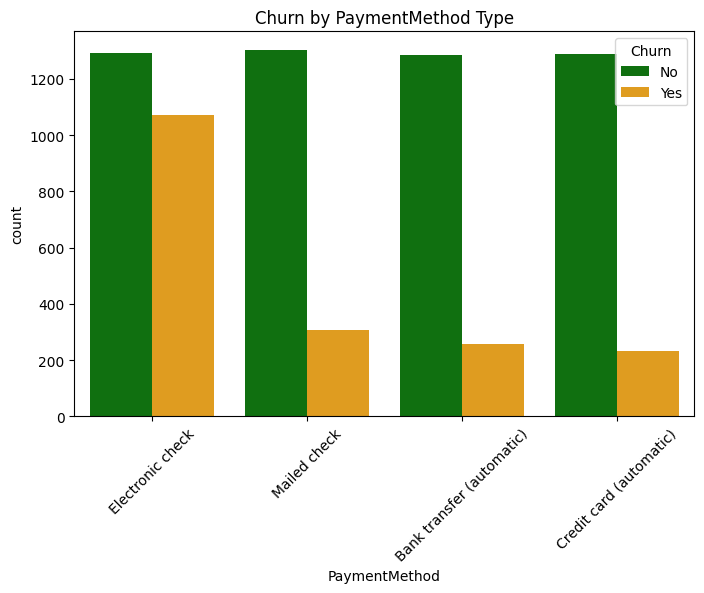

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette=['green', 'orange'])
plt.title('Churn by PaymentMethod Type')
plt.xticks(rotation = 45)
plt.show()

## **`Churn` vs `customer_stage`**

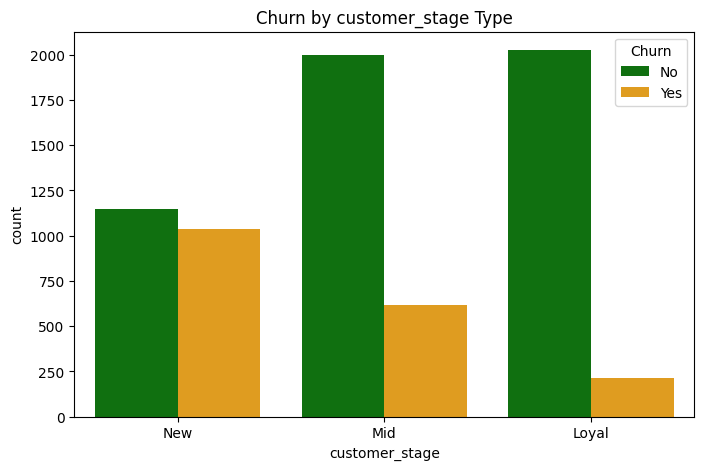

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x='customer_stage', hue='Churn', data=df, palette=['green', 'orange'])
plt.title('Churn by customer_stage Type')
plt.show()

## **`Churn` vs `PaperlessBilling`**

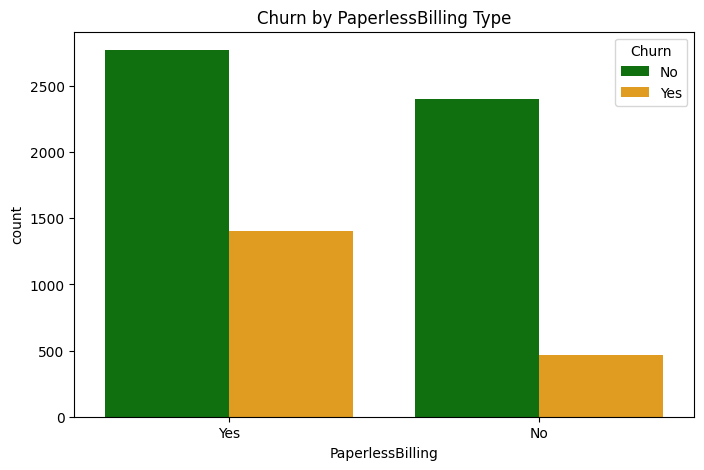

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x='PaperlessBilling', hue='Churn', data=df, palette=['green', 'orange'])
plt.title('Churn by PaperlessBilling Type')
plt.show()

## **Kernel Density Estimation (KDE) Plots for Churn Analysis**

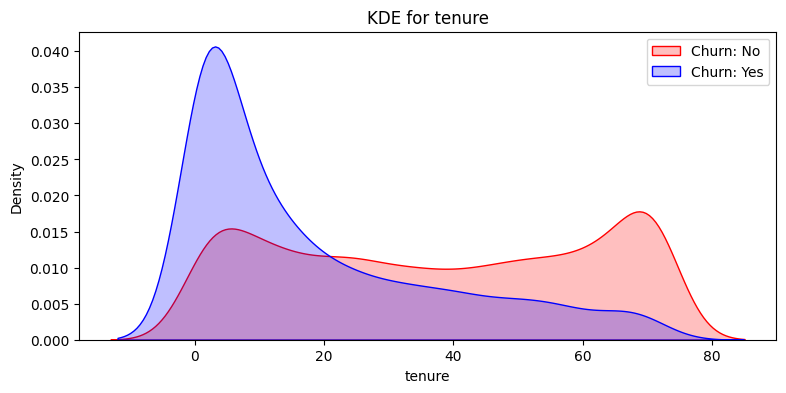

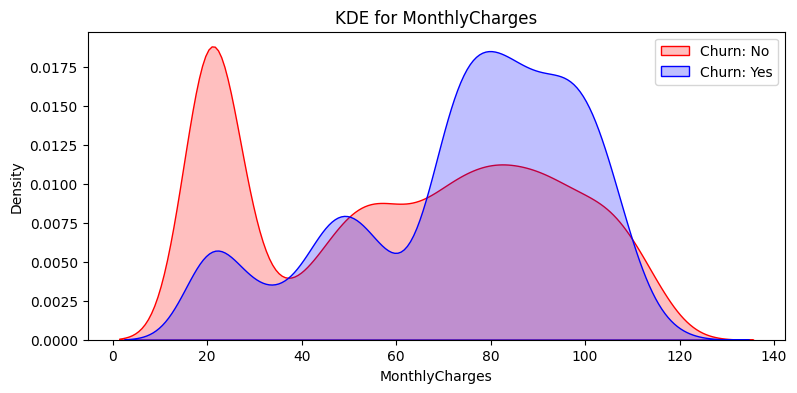

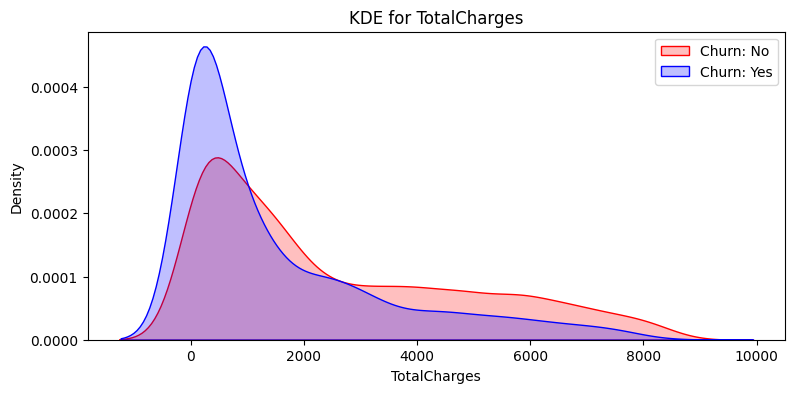

In [28]:
def kdeplot(feature):
    plt.figure(figsize=(9, 4))
    plt.title(f"KDE for {feature}")

    ax0 = sns.kdeplot(df[df['Churn'] == 'No'][feature].dropna(), color='red', label='Churn: No', shade=True)
    ax1 = sns.kdeplot(df[df['Churn'] == 'Yes'][feature].dropna(), color='blue', label='Churn: Yes', shade=True)
    
    plt.legend()  # legend
    plt.show()  # Ensure the plot is displayed properly

kdeplot('tenure')
kdeplot('MonthlyCharges')
kdeplot('TotalCharges')

## **Boxplot of Numeric cols with Churn**

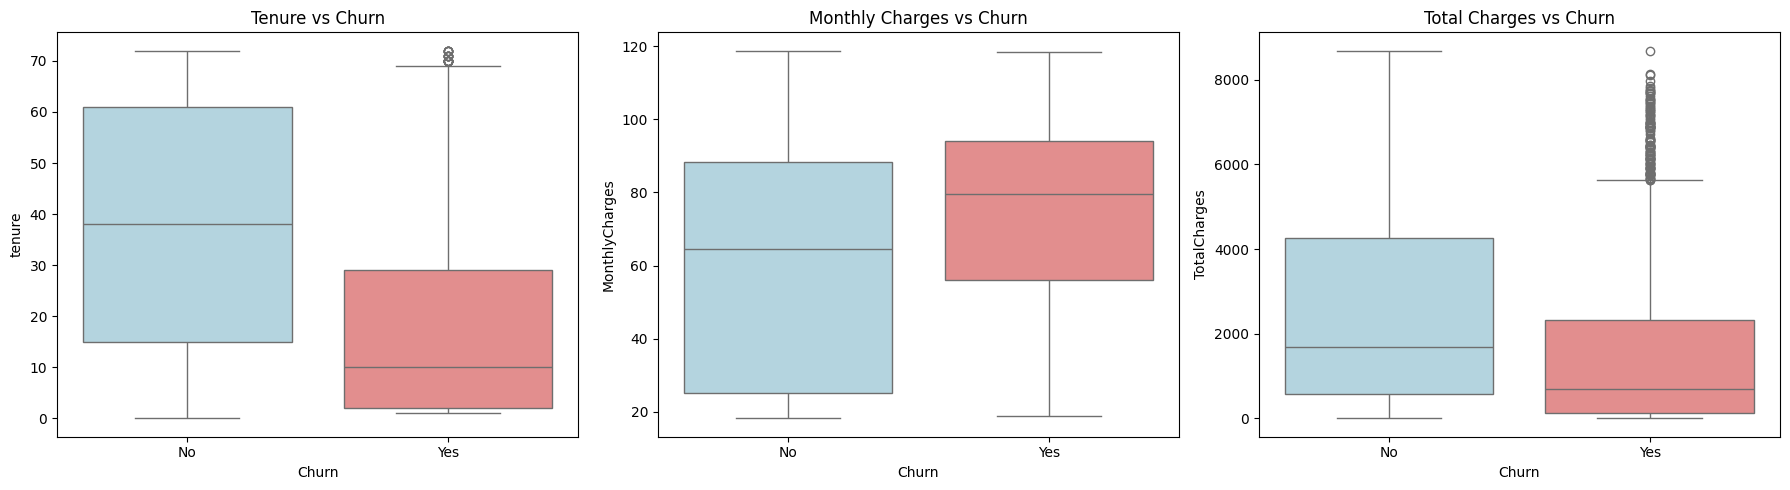

In [29]:
plt.figure(figsize=(18,5))

# tenure vs churn
plt.subplot(1,3,1)
sns.boxplot(x='Churn', y='tenure', data=df,
            palette=['lightblue','lightcoral'])
plt.title("Tenure vs Churn")

# MonthlyCharges vs churn
plt.subplot(1,3,2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            palette=['lightblue','lightcoral'])
plt.title("Monthly Charges vs Churn")

# TotalCharges vs churn
plt.subplot(1,3,3)
sns.boxplot(x='Churn', y='TotalCharges', data=df,
            palette=['lightblue','lightcoral'])
plt.title("Total Charges vs Churn")

plt.tight_layout()
plt.show()

## **Pie Charts**

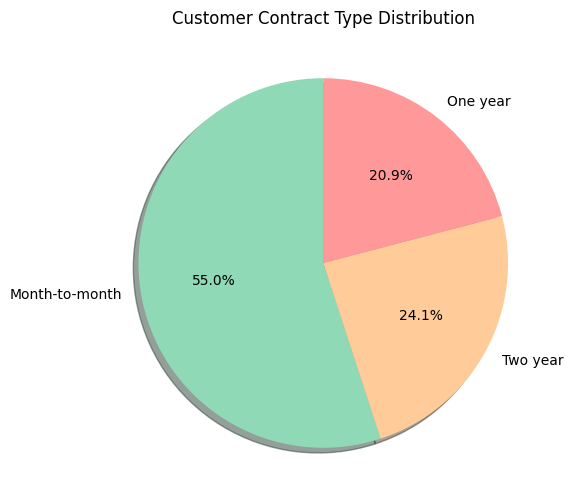

In [30]:
contract_counts = df['Contract'].value_counts()

plt.figure(figsize=(6,6))

colors = ['#8fd9b6', '#ffcc99', '#ff9999']   

plt.pie(contract_counts,
        labels=contract_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        shadow=True)

plt.title("Customer Contract Type Distribution")
plt.show()

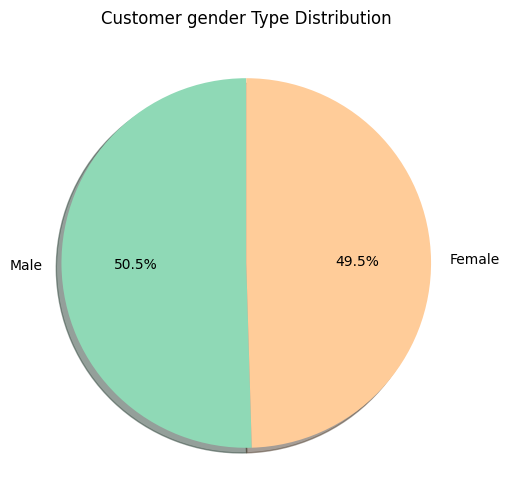

In [31]:
contract_counts = df['gender'].value_counts()

plt.figure(figsize=(6,6))

colors = ['#8fd9b6', '#ffcc99', '#ff9999']   # soft green, peach, soft red

plt.pie(contract_counts,
        labels=contract_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        shadow=True)

plt.title("Customer gender Type Distribution")
plt.show()

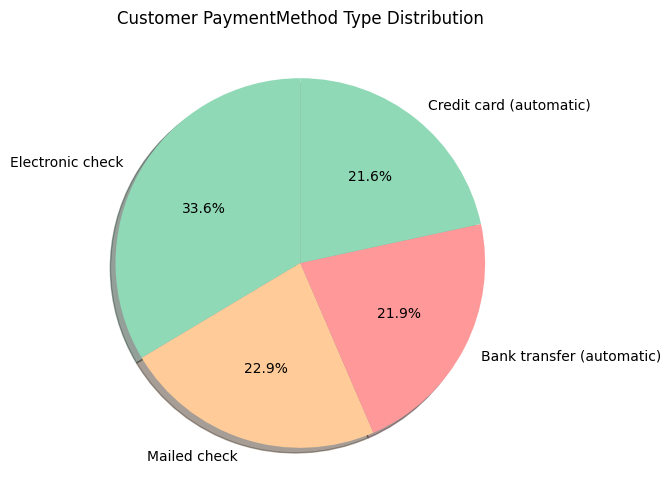

In [32]:
contract_counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(6,6))

colors = ['#8fd9b6', '#ffcc99', '#ff9999']   # soft green, peach, soft red

plt.pie(contract_counts,
        labels=contract_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        shadow=True)

plt.title("Customer PaymentMethod Type Distribution")
plt.show()

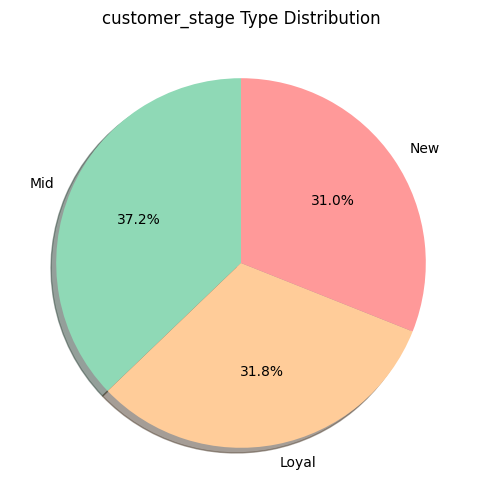

In [33]:
contract_counts = df['customer_stage'].value_counts()

plt.figure(figsize=(6,6))

colors = ['#8fd9b6', '#ffcc99', '#ff9999']   # soft green, peach, soft red

plt.pie(contract_counts,
        labels=contract_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        shadow=True)

plt.title("customer_stage Type Distribution")
plt.show()

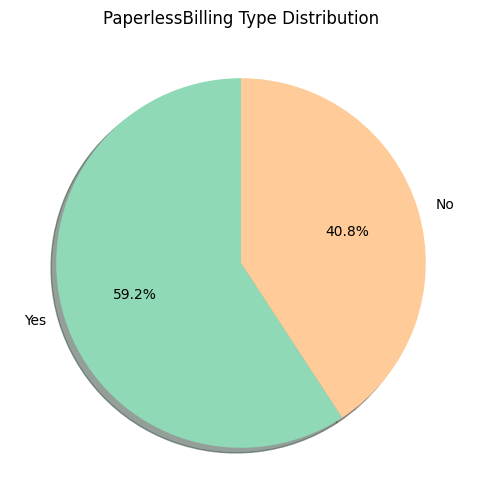

In [34]:
contract_counts = df['PaperlessBilling'].value_counts()

plt.figure(figsize=(6,6))

colors = ['#8fd9b6', '#ffcc99', '#ff9999']   # soft green, peach, soft red

plt.pie(contract_counts,
        labels=contract_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        shadow=True)

plt.title("PaperlessBilling Type Distribution")
plt.show()

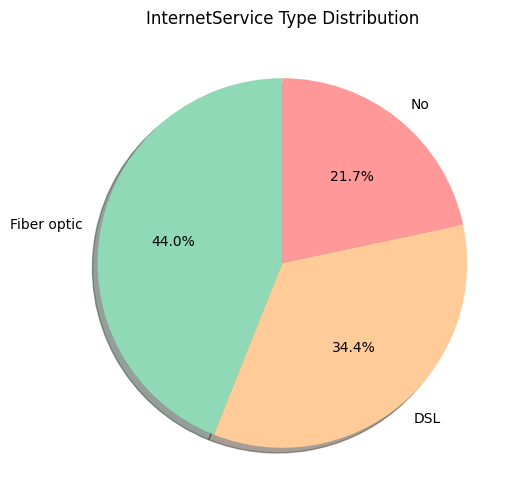

In [35]:
contract_counts = df['InternetService'].value_counts()

plt.figure(figsize=(6,6))

colors = ['#8fd9b6', '#ffcc99', '#ff9999']   # soft green, peach, soft red

plt.pie(contract_counts,
        labels=contract_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        shadow=True)

plt.title("InternetService Type Distribution")
plt.show()

In [36]:
df.to_csv("churn_dashboard.csv", index=False)

## **Key Insights from Visualization**

`Churn vs Tenure`: Customers with lower tenure are more likely to churn, while long-term customers demonstrate stronger retention and loyalty.

`Churn vs MonthlyCharges`: Customers with higher monthly charges tend to show a greater likelihood of churn, indicating sensitivity to pricing or perceived service value.

`Churn vs Contract`: Customers on month-to-month contracts exhibit the highest churn risk, while long-term contract users show significantly better retention

`Churn vs InternetService`: Customers using fiber optic internet services tend to have higher churn rates compared to DSL or customers without internet service.

`Churn vs PaymentMethod`: Customers using electronic check as their payment method show a higher tendency to churn compared to those using automatic or card-based payments.

`Churn vs Customer Stage`: New customers show the highest churn likelihood, while mid-tenure and loyal customers demonstrate progressively stronger retention behavior.

`Churn vs PaperlessBilling`: Customers using paperless billing exhibit slightly higher churn tendencies, indicating a potential association between digital billing preference and churn risk.

KDE – `Tenure Distribution`: Churned customers are concentrated in lower tenure ranges, indicating higher early-stage attrition.

KDE – `MonthlyCharges Distribution`: Customers with higher monthly charges show greater churn density, reflecting potential price sensitivity.

KDE – `TotalCharges Distribution`: Lower total spending customers exhibit higher churn likelihood, while long-term high-spending customers demonstrate stronger retention.

Boxplot – `Tenure vs Churn`: Churned customers show lower median tenure with presence of high-tenure outliers, indicating a few long-term customers also discontinue services.

Boxplot – `MonthlyCharges vs Churn`: Customers who churn generally have a higher median monthly charge with noticeable upper-range outliers, suggesting extreme pricing cases influence churn behaviour.

Boxplot – `TotalCharges vs Churn`: Non-churn customers exhibit higher median total charges with several high-value outliers, reflecting strong revenue contribution from long-tenure loyal customers.

Pie Chart – `Churn Distribution`: A smaller yet significant portion of customers have churned, indicating the need for targeted retention strategies.

Pie Chart – `Contract Distribution`: The majority of customers are subscribed to month-to-month contracts, highlighting a potentially unstable customer base.

Pie Chart – `InternetService Distribution`: A substantial share of customers use fiber optic internet services, reflecting modern high-speed service adoption.

Pie Chart – `PaymentMethod Distribution`: Electronic check is the most commonly used payment method, suggesting a dominant billing preference among customers.

Pie Chart – `Gender Distribution`: Customer base shows a nearly balanced gender composition, indicating minimal demographic skew.

Pie Chart – `PaperlessBilling Distribution`: A large proportion of customers prefer paperless billing, reflecting a shift towards digital service engagement.

Pie Chart – `Customer Stage Distribution`: The customer base is primarily composed of new and mid-tenure users, with a smaller proportion of loyal long-tenure customers, indicating potential retention improvement opportunities.

## **Conclusion**

* Customers with longer tenure demonstrate significantly lower churn probability, therefore telecom providers should introduce targeted onboarding offers and engagement programs for newly acquired customers to strengthen early retention.

* Promoting long-term subscription contracts such as one-year and two-year plans through discounts or bundled benefits can effectively improve customer loyalty and reduce churn risk.

* Higher churn among fiber optic internet users suggests the need to enhance service quality, pricing transparency, and perceived value of high-speed internet offerings.

* Customers using electronic check payment methods exhibit higher churn tendencies, indicating an opportunity to improve digital payment convenience and encourage automated payment options.

* Since churn risk is concentrated during the initial tenure period (first 12–15 months), telecom companies should implement proactive retention strategies such as personalized offers, service upgrades, and customer support engagement during this critical phase.

* Pricing sensitivity observed among customers with higher monthly charges highlights the importance of flexible pricing plans and value-based service bundles to maintain customer satisfaction and long-term retention.

-------

# **12.Encoding and Feature Engineering**

## **Cleaning Categorical Columns for Consistency**

In [37]:
# Replacing 'No phone service' -->> NO
# Replacing 'No internet Service' -->> No

df['MultipleLines'].replace('No phone service','No',inplace=True)
df['OnlineSecurity'].replace('No internet service','No',inplace=True)
df['OnlineBackup'].replace('No internet service','No',inplace=True)
df['DeviceProtection'].replace('No internet service','No',inplace=True)
df['TechSupport'].replace('No internet service','No',inplace=True)
df['StreamingTV'].replace('No internet service','No',inplace=True)
df['StreamingMovies'].replace('No internet service','No',inplace=True)

## **Converting Yes/No Columns to Binary (0/1)**

In [38]:
columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                  'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in columns:
    df[col].replace({'Yes': 1,'No': 0},inplace=True)

In [39]:
df['gender'].replace({'Female':1,'Male':0},inplace=True)

In [40]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customer_stage
0,1,0,1,0,1,0,0,DSL,0,1,...,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0,New
1,0,0,0,0,34,1,0,DSL,1,0,...,0,0,0,One year,0,Mailed check,56.95,1889.50,0,Mid
2,0,0,0,0,2,1,0,DSL,1,1,...,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,New
3,0,0,0,0,45,0,0,DSL,1,0,...,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,Mid
4,1,0,0,0,2,1,0,Fiber optic,0,0,...,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,New


## **Encoding Categorical Variables using One-Hot Encoding**

In [41]:
df2 = pd.get_dummies(data=df, columns=['InternetService','Contract','PaymentMethod'], dtype=int)
df2.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1
3,0,0,0,0,45,0,0,1,0,1,...,1,0,0,0,1,0,1,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


In [42]:
df2.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
customer_stage                              object
InternetService_DSL                          int64
InternetService_Fiber optic    

-------

# **13.Machine Learning Model and Predictions**

In [43]:
df2 = df2.drop('customer_stage', axis=1)

## **Define Feature Matrix and Target**

In [44]:
X = df2.drop('Churn', axis=1)
y = df2['Churn']

## **Train-Test Split**

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## **Random Forest Model**

In [46]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

## **Gradient Boosting Model**

In [47]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

## **Model Evaluation**

In [48]:
# Random Forest Evaluation
print("===== Random Forest =====")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

print("\n")

# Gradient Boosting Evaluation
print("===== Gradient Boosting =====")
print("Accuracy :", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall   :", recall_score(y_test, gb_pred))
print("F1 Score :", f1_score(y_test, gb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, gb_pred))

===== Random Forest =====
Accuracy : 0.8019872249822569
Precision: 0.6643598615916955
Recall   : 0.5133689839572193
F1 Score : 0.579185520361991
Confusion Matrix:
 [[938  97]
 [182 192]]


===== Gradient Boosting =====
Accuracy : 0.8026969481902059
Precision: 0.6655172413793103
Recall   : 0.516042780748663
F1 Score : 0.5813253012048193
Confusion Matrix:
 [[938  97]
 [181 193]]


In [49]:
with open("rf_churn_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [50]:
with open("gb_churn_model.pkl", "wb") as f:
    pickle.dump(gb, f)

In [51]:
pickle.dump(X.columns, open("model_features.pkl","wb"))